# Neural Network for ECG Classification



all lead ecg ml with resnet model



#### IMPORTS

In [1]:
import numpy as np

from dataloader import MyCustomDataset
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim

import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from selfeeg.models import ResNet1D


In [2]:
default_dir = os.getcwd()
def default_directory():
    os.chdir(f"{default_dir}")
    print(f"you are back to the default directory: {default_dir}")


In [3]:
default_directory()
os.getcwd()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


'/home/karansingh/Documents/summer term/ECG_ML/MAIN'

In [4]:
os.chdir("data_prep")
os.getcwd()

'/home/karansingh/Documents/summer term/ECG_ML/MAIN/data_prep'

In [5]:
# get list of all files in the directory
files = os.listdir()
print(files)

['README copy', 'unq_disease_SB.npy', 'disease_SR.npy', 'data_prep.ipynb', 'disease_SB.npy', 'EXPERIMENT_resnet', 'disease_ST.npy', 'unq_disease_SR.npy', 'README.md', 'EXPERIMENT_2', 'data_prep_for_only_one_disease.ipynb', 'EXPERIMENT_resnet_1d', 'unq_disease_ST.npy']


#### LOAD DATA

In [6]:
data_ST_list = np.load("unq_disease_ST.npy")
data_SB_list = np.load("unq_disease_SB.npy")
data_SR_list = np.load("unq_disease_SR.npy")
#print shape of all loaded files
print("shape of ST data: ", data_ST_list.shape)
print("shape of SB data: ", data_SB_list.shape)
print("shape of SR data: ", data_SR_list.shape)



shape of ST data:  (3000, 5000, 12)
shape of SB data:  (5000, 5000, 12)
shape of SR data:  (5000, 5000, 12)


### sanity check

In [7]:
# check the curupted data
def check_data(data):
    corrupted_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any() or np.isinf(data[i]).any():
            corrupted_indices.append(i)
    return corrupted_indices
corrupted_ST = check_data(data_ST_list)
corrupted_SB = check_data(data_SB_list)
corrupted_SR = check_data(data_SR_list)
print("corrupted ST indices: ", corrupted_ST)
print("corrupted SB indices: ", corrupted_SB)
print("corrupted SR indices: ", corrupted_SR)


corrupted ST indices:  [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]
corrupted SB indices:  [1418, 1852, 1898, 2756, 2881, 3007, 3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]
corrupted SR indices:  [149, 192, 213, 340, 385, 441, 2341, 2451, 2482, 2534, 4903, 4944]


In [8]:
# now che ck nana and inf difrently
def check_nan_inf(data):
    nan_indices = []
    inf_indices = []
    for i in range(data.shape[0]):
        if np.isnan(data[i]).any():
            nan_indices.append(i)
        if np.isinf(data[i]).any():
            inf_indices.append(i)
    return nan_indices, inf_indices
nan_ST, inf_ST = check_nan_inf(data_ST_list)
nan_SB, inf_SB = check_nan_inf(data_SB_list)
nan_SR, inf_SR = check_nan_inf(data_SR_list)
print("NaN ST indices: ", nan_ST)
print("Inf ST indices: ", inf_ST)
print("NaN SB indices: ", nan_SB)
print("Inf SB indices: ", inf_SB)
print("NaN SR indices: ", nan_SR)
print("Inf SR indices: ", inf_SR)


NaN ST indices:  [199, 306, 449, 633, 920, 2132, 2141, 2186, 2256]
Inf ST indices:  []
NaN SB indices:  [1418, 1852, 1898, 2756, 2881, 3007, 3101, 4091, 4192, 4293, 4376, 4594, 4601, 4720]
Inf SB indices:  []
NaN SR indices:  [149, 192, 213, 340, 385, 441, 2341, 2451, 2482, 2534, 4903, 4944]
Inf SR indices:  []


In [9]:
# remove corrupted data from all three datasets
def remove_corrupted_data(data_list, corrupted_indices):
    return np.delete(data_list, corrupted_indices, axis=0)
    return cleaned_data

data_ST_list = remove_corrupted_data(data_ST_list, nan_ST + inf_ST)
data_SB_list = remove_corrupted_data(data_SB_list, nan_SB + inf_SB)
data_SR_list = remove_corrupted_data(data_SR_list, nan_SR + inf_SR)

### creating batches


In [10]:

# lead 1
# Use ALL 12 leads
images = data_ST_list          # shape: (N_ST, T, 12)
labels = np.zeros(images.shape[0])

# SB
images = np.concatenate((images, data_SB_list), axis=0)
labels = np.concatenate((labels, np.ones(data_SB_list.shape[0])))

# SR
images = np.concatenate((images, data_SR_list), axis=0)
labels = np.concatenate((labels, 2*np.ones(data_SR_list.shape[0])))

print("we have", images.shape[0], "samples and", labels.shape[0], "labels")
print("raw shape:", images.shape)

                    

we have 12965 samples and 12965 labels
raw shape: (12965, 5000, 12)


In [11]:
len(images),len(labels)

(12965, 12965)

In [12]:
from sklearn.model_selection import train_test_split

X = images        # (12965, 5000, 12)
y = labels      # (12965,)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

#split is of 70% train, 15% val, 15% test


In [13]:
# compute stats on TRAIN set only
mean = X_train.mean(axis=(0, 1))   # (12,)
std  = X_train.std(axis=(0, 1))    # (12,)

std[std < 1e-6] = 1e-6  # safety


In [14]:
# apply normalization
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std


#### transposing data

In [15]:
# (batch, time, channels) → (batch, channels, time)
X_train = X_train.transpose(0, 2, 1)
X_val   = X_val.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)


In [16]:
import torch
from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_ds = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)

test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_dataloader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dataloader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_ds, batch_size=32, shuffle=False)

#### CREATE BATCHES

In [17]:
# # 70% train, 15% val, 15% test split
# images_train, images_temp, labels_train, labels_temp = train_test_split(
#     images, labels, train_size=0.70, random_state=42
# )
# images_val, images_test, labels_val, labels_test = train_test_split(
#     images_temp, labels_temp, test_size=0.5, random_state=42
# )

# train_dataset = MyCustomDataset_resnet(images_train, labels_train)
# val_dataset   = MyCustomDataset_resnet(images_val, labels_val)
# test_dataset  = MyCustomDataset_resnet(images_test, labels_test)

# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


## model


#### TRAINING PARAMETERS

#### TRAINING

# 1D resnet

In [18]:
model = ResNet1D(
    nb_classes=3,
    Chans=12,
    Samples=1000,
    Layers=[2, 2, 2, 2],   # same as your 4 layers with 2 blocks each
    inplane=32,             # equivalent to base_channels=32
    kernLength=7
)

In [19]:
x, y = next(iter(train_dataloader))
print(x.shape)

torch.Size([32, 12, 5000])


In [20]:
import copy
import torch
import torch.nn as nn
import numpy as np
import os
import time
from datetime import datetime
from IPython.display import clear_output
default_directory()

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# === Settings ===
num_epochs, patience = 25, 7

# Get the notebook name
try:
    from IPython import get_ipython
    notebook_name = get_ipython().user_ns.get('__vsc_ipynb_file__', None)
    if notebook_name is None:
        import ipynbname
        notebook_name = ipynbname.name()
    notebook_name = os.path.splitext(os.path.basename(notebook_name))[0]
except:
    notebook_name = "image_resnet_type_1"

log_dir = "EXPERIMENT_resnet_1d_selfeeg"
os.makedirs(log_dir, exist_ok=True)
log_path = os.path.join(log_dir, f"{notebook_name}.txt")

# Utility function to log both to console and file
def log_print(msg, f):
    print(msg)
    f.write(msg + "\n")
    f.flush()

clear_output(wait=True)
with open(log_path, "a") as f:
    log_print("\n" + "="*60, f)
    log_print(f"Training Run Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", f)
    log_print("="*60, f)

    model = ResNet1D(nb_classes=3, Chans=12, Samples=5000, Layers=[2,2,2,2], inplane=32, kernLength=7).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    def correct(pred, true):
        return (pred == true).sum().item()

    train_losses_list, val_losses_list = [], []
    accuracy_train_list, accuracy_val_list = [], []
    best_acc, wait, best_model = 0, 0, None

    # Start total training timer
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # --- Train ---
        model.train()
        run_loss = 0
        c_train = t_train = 0
        train_start_time = time.time()
        
        for x, y in train_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            run_loss += loss.item()
            c_train += correct(out.argmax(1), y)
            t_train += y.size(0)

        train_time = time.time() - train_start_time
        train_losses_list.append(run_loss / len(train_dataloader))
        accuracy_train_list.append(100 * c_train / t_train)

        # --- Validation ---
        model.eval()
        run_loss = 0
        c_val = t_val = 0
        val_start_time = time.time()
        
        with torch.no_grad():
            for x, y in val_dataloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                run_loss += loss.item()
                c_val += correct(out.argmax(1), y)
                t_val += y.size(0)

        val_time = time.time() - val_start_time
        val_losses_list.append(run_loss / len(val_dataloader))
        accuracy_val_list.append(100 * c_val / t_val)

        # --- LR scheduler ---
        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_losses_list[-1])
        lr_now = optimizer.param_groups[0]["lr"]
        
        # Manual verbose logging
        if lr_now != old_lr:
            log_print(f"  >> Learning rate reduced: {old_lr:.6f} -> {lr_now:.6f}", f)

        # --- Early stopping ---
        if accuracy_val_list[-1] > best_acc:
            best_acc, wait = accuracy_val_list[-1], 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            wait += 1
            if wait >= patience:
                log_print(f"## Early stopping at epoch {epoch + 1} ##", f)
                break

        epoch_time = time.time() - epoch_start_time
        
        log_print(
            f"Epoch [{epoch + 1}/{num_epochs}] | "
            f"Train Loss: {train_losses_list[-1]:.4f}, Val Loss: {val_losses_list[-1]:.4f}, "
            f"Train Acc: {accuracy_train_list[-1]:.2f}%, Val Acc: {accuracy_val_list[-1]:.2f}%, "
            f"LR: {lr_now:.6f} | "
            f"Time: {epoch_time:.2f}s (Train: {train_time:.2f}s, Val: {val_time:.2f}s)",
            f,
        )

    total_training_time = time.time() - total_start_time

    # Restore best weights and save
    model.load_state_dict(best_model)
    torch.save(best_model, os.path.join(log_dir, f"{notebook_name}.pth"))
    log_print(f"\nBest Validation Accuracy: {best_acc:.2f}%", f)

    # --- Test accuracy ---
    model.eval()
    c_test = t_test = 0
    test_start_time = time.time()
    
    with torch.no_grad():
        for x, y in test_dataloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            c_test += correct(out.argmax(1), y)
            t_test += y.size(0)
    
    test_time = time.time() - test_start_time
    test_acc = 100 * c_test / t_test
    log_print(f"Test Accuracy: {test_acc:.2f}% (Time: {test_time:.2f}s)", f)
    
    log_print("="*60, f)
    log_print(f"Total Training Time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)", f)
    log_print("✅ Training complete.", f)


Training Run Started: 2026-03-07 22:13:10
Epoch [1/25] | Train Loss: 0.3687, Val Loss: 0.1656, Train Acc: 84.30%, Val Acc: 93.11%, LR: 0.001000 | Time: 247.55s (Train: 233.35s, Val: 14.20s)
Epoch [2/25] | Train Loss: 0.2298, Val Loss: 0.1513, Train Acc: 90.93%, Val Acc: 93.93%, LR: 0.001000 | Time: 256.60s (Train: 242.38s, Val: 14.21s)
Epoch [3/25] | Train Loss: 0.1661, Val Loss: 0.3608, Train Acc: 93.83%, Val Acc: 90.54%, LR: 0.001000 | Time: 248.65s (Train: 234.45s, Val: 14.20s)
Epoch [4/25] | Train Loss: 0.1321, Val Loss: 0.1003, Train Acc: 94.98%, Val Acc: 97.63%, LR: 0.001000 | Time: 248.71s (Train: 234.50s, Val: 14.21s)
Epoch [5/25] | Train Loss: 0.1200, Val Loss: 0.1702, Train Acc: 95.52%, Val Acc: 94.19%, LR: 0.001000 | Time: 248.77s (Train: 234.56s, Val: 14.21s)
Epoch [6/25] | Train Loss: 0.1068, Val Loss: 0.0723, Train Acc: 96.01%, Val Acc: 97.79%, LR: 0.001000 | Time: 248.74s (Train: 234.53s, Val: 14.21s)
Epoch [7/25] | Train Loss: 0.0954, Val Loss: 0.7223, Train Acc: 96.51

CONFUSION MATRIX


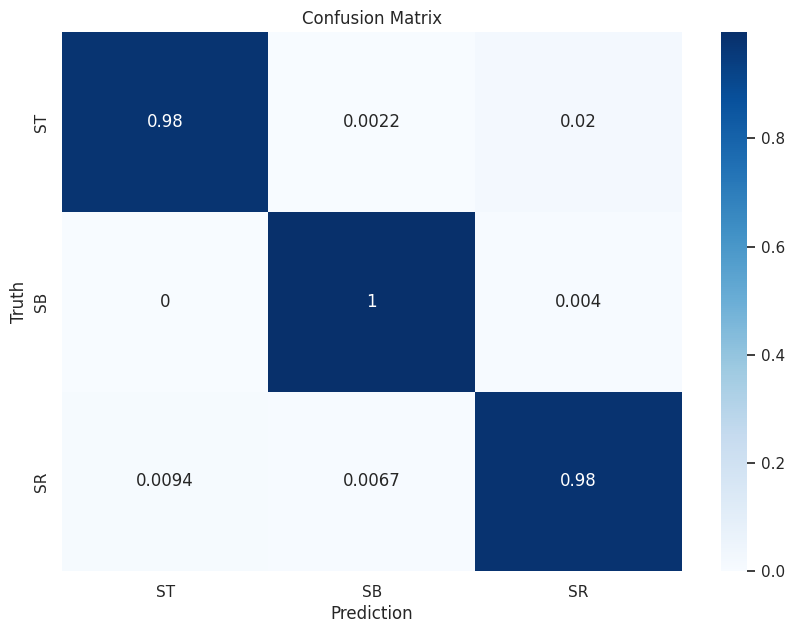


MICRO-AVERAGED PRECISION-RECALL CURVE
Average precision score, micro-averaged over all classes: 1.00


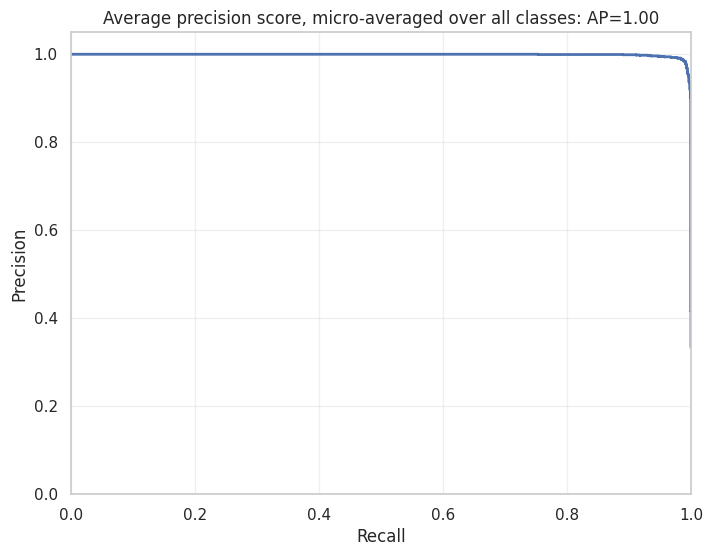


PER-CLASS PRECISION-RECALL CURVES


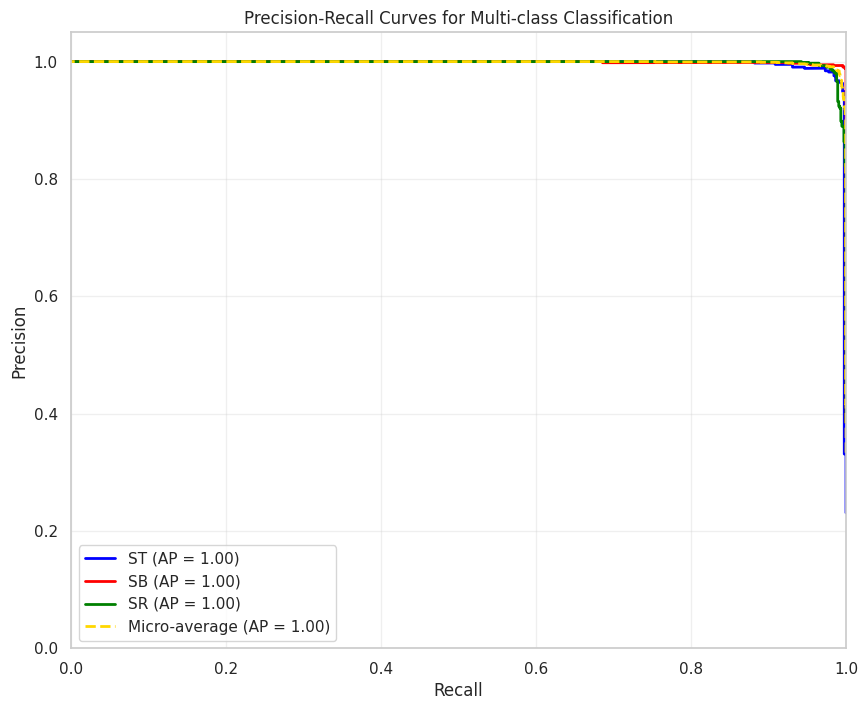


ROC CURVES


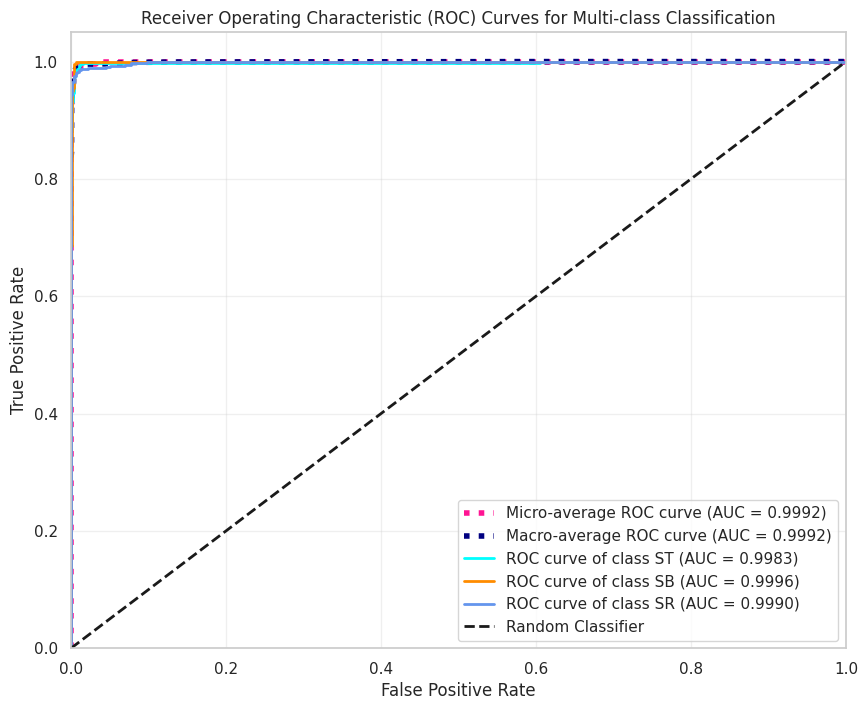

AUC Scores:
Class ST: 0.9983
Class SB: 0.9996
Class SR: 0.9990
Micro-average: 0.9992
Macro-average: 0.9992

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          ST     0.9843    0.9777    0.9810       449
          SB     0.9920    0.9960    0.9940       748
          SR     0.9840    0.9840    0.9840       748

    accuracy                         0.9871      1945
   macro avg     0.9868    0.9859    0.9863      1945
weighted avg     0.9871    0.9871    0.9871      1945


EVALUATION COMPLETE
you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


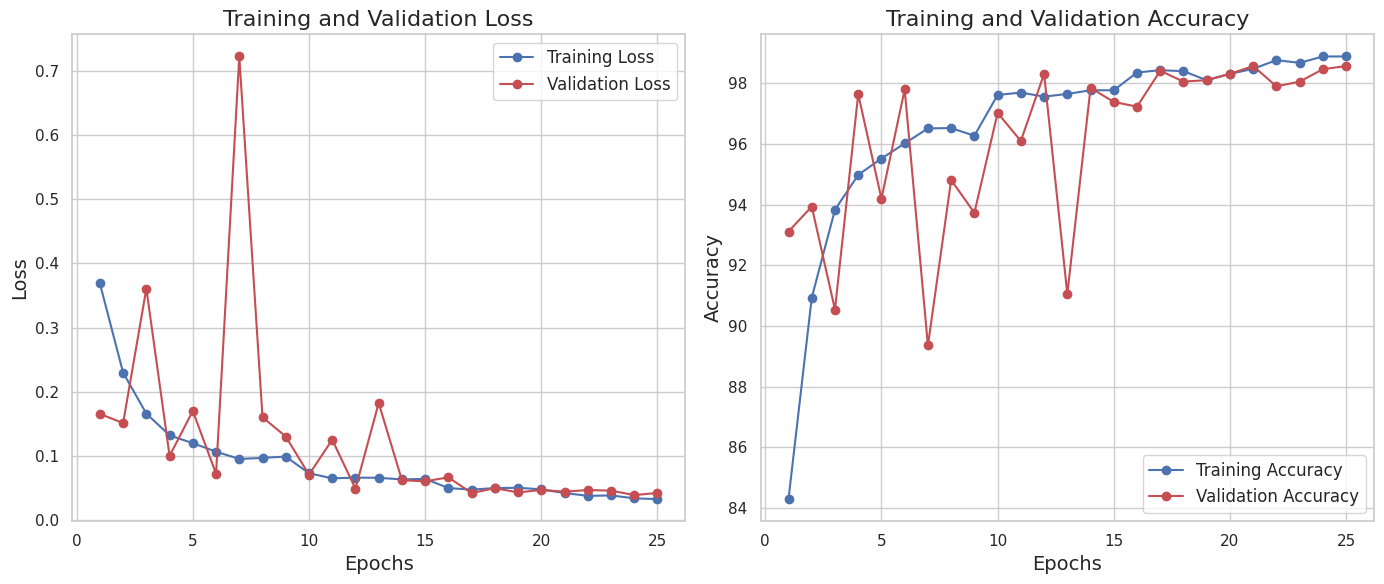

In [21]:
from plots import evaluate_all
# Selective plotting
results = evaluate_all(
    model, test_dataloader, device,
    plot_confusion_matrix=True,
    plot_pr_micro=True,
    plot_pr_per_class=True,
    plot_roc=True,
    print_report=True
)

default_directory()
from plots import accuracy_and_validation_plots


# Example data: Replace these with your actual training and validation data
epochs_= list(range(1, len(train_losses_list)+1))

accuracy_and_validation_plots(epochs_, train_losses_list, val_losses_list, accuracy_train_list,accuracy_val_list).plot_figure("accuracy.png")


In [22]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 2,451,363
Trainable parameters: 2,451,363


In [24]:
default_directory()

you are back to the default directory: /home/karansingh/Documents/summer term/ECG_ML/MAIN


In [29]:
from model_cnn import SmallCNN
model2= SmallCNN().to(device)


In [30]:
total_params = sum(p.numel() for p in model2.parameters())
trainable_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 1,143,747
Trainable parameters: 1,143,747
